# Sex differences in Sun et al. BM scRNA-seq

This notebook looks at sex differences in the Sun et al. CD34+ bone marrow scRNA-seq dataset (Immunity 2024; GSE248728/30).

Here I will load cell and donor metadata (with inferred sex), do some quick QC-style summaries, and save simple tables for downstream analyses.

In [1]:
# Imports for data handling and visualization
import gzip
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)

# Set base directory to the repo root (adjust if you run from elsewhere)
BASE_DIR = Path(".").resolve()
BASE_DIR

PosixPath('/Users/fsfatemi/sun_et_al')

## Load metadata and donor sex

I load per-cell metadata and merge in donor-level sex calls (M/F) so each cell carries its donor’s inferred sex label.

In [3]:
# Paths to existing metadata files (relative to repo root)
cell_meta_path = BASE_DIR / 'scRNA_cell_metadata.tsv.gz'
donor_sex_path = BASE_DIR / 'donor_sex.csv'

# print('Cell metadata path:', cell_meta_path)
# print('Donor sex path:', donor_sex_path)

# Load per-cell metadata (produced previously by make_scRNA_metadata_summary.py)
if not cell_meta_path.exists():
    raise FileNotFoundError(f'Missing {cell_meta_path}. Ensure you have run make_scRNA_metadata_summary.py or placed the file in the repo root.')

with gzip.open(cell_meta_path, 'rt') as f:
    cell_meta = pd.read_csv(f, sep='\t')

# print('Cell metadata shape:', cell_meta.shape)
# cell_meta.head()

In [5]:
# Load donor-level sex mapping inferred from scRNA (existing file)
if not donor_sex_path.exists():
    raise FileNotFoundError(f'Missing {donor_sex_path}. Run your sex-inference script first (e.g., simple_sex_inference.py).')

donor_sex = pd.read_csv(donor_sex_path)
print('Donor sex table:')
display(donor_sex)

# Merge donor sex onto per-cell metadata
cell_meta = cell_meta.merge(donor_sex, on='donor', how='left')

# print('After merging sex, missing values per column:')
# print(cell_meta.isna().sum())

# Drop cells without a sex label if any (or keep and flag, depending on preference)
cell_meta_sex = cell_meta.dropna(subset=['sex']).copy()
print('Cells with sex label:', len(cell_meta_sex))
cell_meta_sex.head()

Donor sex table:


,donor,sex
0,S1,M
1,S10,M
2,S11,F
3,S12,F
4,S13,F
5,S14,F
6,S15,F
7,S16,M
8,S17,M
9,S18,M


Cells with sex label: 103663


,capture,barcode,best,call_type,timepoint,vaccination,unique_id,donor,sex_x,sex_y,sex
0,capture10,AAACCCAAGGGTTAAT,SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001,singlet,Tm3,BCG,SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001_Tm3_BCG,S10,M,M,M
1,capture10,AAACCCACAAAGTATG,SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001,singlet,Tm3,BCG,SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001_Tm3_BCG,S1,M,M,M
2,capture10,AAACCCACAATCGTCA,SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001,singlet,Tm3,BCG,SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001_Tm3_BCG,S1,M,M,M
3,capture10,AAACCCACACATACTG,SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001,singlet,Tm3,BCG,SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001_Tm3_BCG,S10,M,M,M
4,capture10,AAACCCACAGGTACGA,SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001,singlet,Tm3,BCG,SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001_Tm3_BCG,S10,M,M,M


Before modeling, I sanity-check the design: how many cells we have per donor, capture, and sex, and (if available) across timepoints and vaccination groups. This helps flag any major imbalances that could confound sex effects.

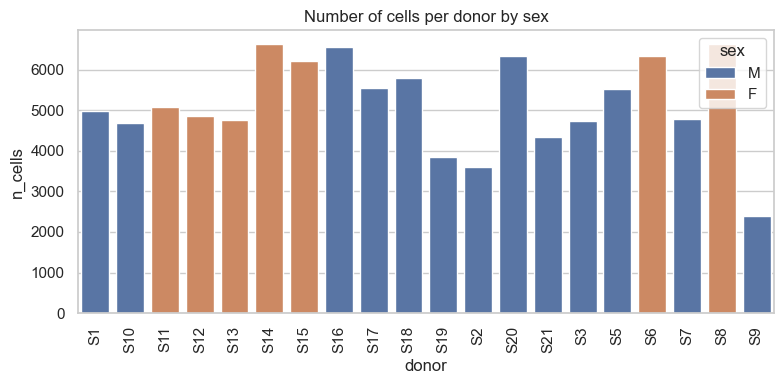

,donor,sex,n_cells
0,S1,M,4990
1,S10,M,4681
2,S11,F,5079
3,S12,F,4867
4,S13,F,4767


In [6]:
# Cells per donor, colored by sex
cells_per_donor = (
    cell_meta_sex.groupby(['donor', 'sex'])
    .size()
    .reset_index(name='n_cells')
)

plt.figure(figsize=(8, 4))
sns.barplot(data=cells_per_donor, x='donor', y='n_cells', hue='sex')
plt.xticks(rotation=90)
plt.title('Number of cells per donor by sex')
plt.tight_layout()
plt.show()

cells_per_donor.head()

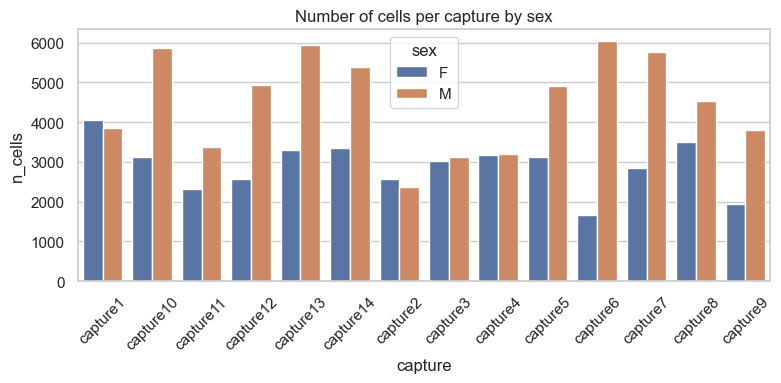

In [7]:
# If 'capture' is available, summarize cells per capture and sex
if 'capture' in cell_meta_sex.columns:
    cells_per_capture = (
        cell_meta_sex.groupby(['capture', 'sex'])
        .size()
        .reset_index(name='n_cells')
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(data=cells_per_capture, x='capture', y='n_cells', hue='sex')
    plt.xticks(rotation=45)
    plt.title('Number of cells per capture by sex')
    plt.tight_layout()
    plt.show()

    cells_per_capture.head()
else:
    print("Column 'capture' not found in metadata; skipping capture-level summary.")

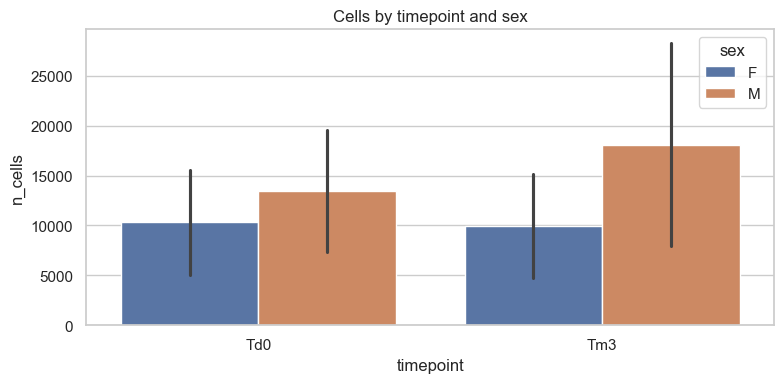

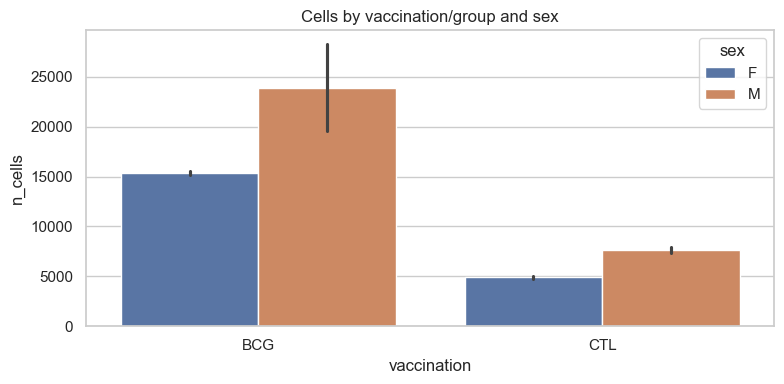

In [8]:
# If timepoint / vaccination-like columns exist, summarize them as well
timepoint_cols = [c for c in ['timepoint', 'Timepoint'] if c in cell_meta_sex.columns]
vacc_cols = [c for c in ['vaccination', 'group'] if c in cell_meta_sex.columns]

if timepoint_cols and vacc_cols:
    t_col = timepoint_cols[0]
    v_col = vacc_cols[0]
    cells_by_tv_sex = (
        cell_meta_sex.groupby([t_col, v_col, 'sex'])
        .size()
        .reset_index(name='n_cells')
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(data=cells_by_tv_sex, x=t_col, y='n_cells', hue='sex')
    plt.title('Cells by timepoint and sex')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.barplot(data=cells_by_tv_sex, x=v_col, y='n_cells', hue='sex')
    plt.title('Cells by vaccination/group and sex')
    plt.tight_layout()
    plt.show()

    cells_by_tv_sex.head()
else:
    print('No obvious timepoint/vaccination columns found at cell level; these may exist at sample level only.')

## Save metadata summaries

I summarize donors (and, when possible, captures) with sex labels and write these tables to disk so other notebooks and scripts can reuse them.

In [8]:
# Donor-level summary: number of cells and sex
donor_summary = (
    cell_meta_sex.groupby(['donor', 'sex'])
    .size()
    .reset_index(name='n_cells')
)
donor_summary

# Optional: capture-level summary if capture column exists
if 'capture' in cell_meta_sex.columns:
    capture_summary = (
        cell_meta_sex.groupby(['capture', 'donor', 'sex'])
        .size()
        .reset_index(name='n_cells')
    )
else:
    capture_summary = None

# Save to disk for re-use in later notebooks / scripts
out_dir = BASE_DIR / 'analysis_outputs'
out_dir.mkdir(exist_ok=True)

donor_summary_path = out_dir / 'donor_summary_with_sex.csv'
donor_summary.to_csv(donor_summary_path, index=False)
print('Saved donor summary to', donor_summary_path)

if capture_summary is not None:
    capture_summary_path = out_dir / 'capture_summary_with_sex.csv'
    capture_summary.to_csv(capture_summary_path, index=False)
    print('Saved capture summary to', capture_summary_path)

donor_summary.head()

Saved donor summary to /Users/fsfatemi/sun_et_al/analysis_outputs/donor_summary_with_sex.csv
Saved capture summary to /Users/fsfatemi/sun_et_al/analysis_outputs/capture_summary_with_sex.csv


,donor,sex,n_cells
0,S1,M,4990
1,S10,M,4681
2,S11,F,5079
3,S12,F,4867
4,S13,F,4767


## Sample-level metadata in Python

Here I mirror the EMMREML preprocessing at the sample (`UNIQUE_ID`) level: load `all_samples_meta_data_emmreml.csv`, merge in donor sex, look at design balance by sex, and implement the paired-donor filter (donors with both Td0 and Tm3).

In [9]:
# Load sample-level EMMREML metadata and merge sex labels
from pathlib import Path

emmreml_meta_path = BASE_DIR / 'BCG-humanBM-code' / 'scRNA_analyses' / '2_main_analyses' / 'all_samples_meta_data_emmreml.csv'
print('EMMREML metadata path:', emmreml_meta_path)

if not emmreml_meta_path.exists():
    raise FileNotFoundError(f'Missing {emmreml_meta_path}. Make sure the BCG-humanBM-code repo structure matches the original.')

meta_emm = pd.read_csv(emmreml_meta_path)
print('Raw EMMREML metadata head:')
display(meta_emm.head())

# Merge in donor sex
meta_emm_sex = meta_emm.merge(donor_sex, on='donor', how='left')

print('After merging sex, NA counts per column:')
print(meta_emm_sex.isna().sum())

print('\nUnique donors by sex:')
print(meta_emm_sex.drop_duplicates('donor')[['donor', 'sex']].sort_values('donor'))

print('\nSamples per (group, timepoint, sex):')
samples_by_gts = (
    meta_emm_sex
    .groupby(['group', 'timepoint', 'sex'])
    .size()
    .reset_index(name='n_samples')
)
display(samples_by_gts)


EMMREML metadata path: /Users/fsfatemi/sun_et_al/BCG-humanBM-code/scRNA_analyses/2_main_analyses/all_samples_meta_data_emmreml.csv
Raw EMMREML metadata head:


,Sample,timepoint,donor,group,vaccination
0,SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001_Td0_BCG,0,S1,BCG,0
1,SNG-LB-SS-1S-RS-S2-CD34neg_S2_R1_001_Td0_BCG,0,S2,BCG,0
2,SNG-LB-SS-1S-RS-S3-CD34neg_S3_R1_001_Td0_CTL,0,S3,CTL,0
3,SNG-LB-SS-1S-RS-S5-CD34neg_S4_R1_001_Td0_BCG,0,S5,BCG,0
4,SNG-LB-SS-1S-RS-S6-CD34neg_S5_R1_001_Td0_BCG,0,S6,BCG,0


After merging sex, NA counts per column:
Sample         0
timepoint      0
donor          0
group          0
vaccination    0
sex            0
dtype: int64

Unique donors by sex:
   donor sex
0     S1   M
7    S10   M
8    S11   F
9    S12   F
10   S13   F
11   S14   F
12   S15   F
13   S16   M
14   S17   M
15   S18   M
35   S19   M
1     S2   M
16   S20   M
17   S21   M
2     S3   M
3     S5   M
4     S6   F
5     S7   M
6     S8   F
25    S9   M

Samples per (group, timepoint, sex):


,group,timepoint,sex,n_samples
0,BCG,0,F,5
1,BCG,0,M,8
2,BCG,1,F,5
3,BCG,1,M,10
4,CTL,0,F,2
5,CTL,0,M,3
6,CTL,1,F,2
7,CTL,1,M,3


In [10]:
# Helper: restrict to paired donors (both Td0 and Tm3) within each group

def restrict_to_paired_donors(meta_df: pd.DataFrame) -> pd.DataFrame:
    """Return metadata restricted to donors with both timepoints (0 and 1).

    This mimics the R logic where only donors present at both Td0 and Tm3
    are kept for modeling. We do not yet filter by cluster (<20 cells) here;
    that will be done when we have a cluster-specific pseudobulk matrix.
    """
    # donors present at each timepoint
    donors_t0 = set(meta_df.loc[meta_df['timepoint'] == 0, 'donor'])
    donors_t1 = set(meta_df.loc[meta_df['timepoint'] == 1, 'donor'])
    donors_both = donors_t0.intersection(donors_t1)

    print('Number of donors at Td0:', len(donors_t0))
    print('Number of donors at Tm3:', len(donors_t1))
    print('Number of paired donors:', len(donors_both))

    out = meta_df[meta_df['donor'].isin(donors_both)].copy()
    return out


meta_emm_paired = restrict_to_paired_donors(meta_emm_sex)
print('Samples remaining after paired-donor restriction:', len(meta_emm_paired))

meta_emm_paired.head()

Number of donors at Td0: 18
Number of donors at Tm3: 20
Number of paired donors: 18
Samples remaining after paired-donor restriction: 36


,Sample,timepoint,donor,group,vaccination,sex
0,SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001_Td0_BCG,0,S1,BCG,0,M
1,SNG-LB-SS-1S-RS-S2-CD34neg_S2_R1_001_Td0_BCG,0,S2,BCG,0,M
2,SNG-LB-SS-1S-RS-S3-CD34neg_S3_R1_001_Td0_CTL,0,S3,CTL,0,M
3,SNG-LB-SS-1S-RS-S5-CD34neg_S4_R1_001_Td0_BCG,0,S5,BCG,0,M
4,SNG-LB-SS-1S-RS-S6-CD34neg_S5_R1_001_Td0_BCG,0,S6,BCG,0,F


## Cluster-level pseudobulk and gene filtering

For any cluster of interest (for example HSC_a), I want to:
- load its pseudobulk matrix (genes × samples),
- align samples with the paired metadata, and
- optionally apply the same median-expression gene filter used in the R workflow.

I assume cluster-level pseudobulk has been exported to CSV; if it only exists as RDS I can either export from R or read it directly from Python.

In [11]:
# Example: load one cluster's pseudobulk matrix (CSV) and align with metadata

# Choose a cluster of interest (adjust as needed)
cluster_name = 'HSC_a'

# Path where a CSV version of the pseudobulk matrix is stored
# (If you only have RDS, we can export via R separately.)
pseudobulk_csv_path = (
    BASE_DIR
    / 'BCG-humanBM-code'
    / 'scRNA_analyses'
    / '2_main_analyses'
    / 'pseudobulk'
    / f'{cluster_name}_pseudobulk.csv'
)

print('Pseudobulk CSV path:', pseudobulk_csv_path)

if not pseudobulk_csv_path.exists():
    print('WARNING: CSV pseudobulk not found. You may need to export the RDS pseudobulk to CSV first.')
else:
    pseudobulk_df = pd.read_csv(pseudobulk_csv_path, index_col=0)
    print('Raw pseudobulk shape (genes x samples):', pseudobulk_df.shape)

    # Align columns with paired metadata
    # Columns are expected to be sample IDs matching meta_emm_paired['Sample']
    common_samples = sorted(set(pseudobulk_df.columns) & set(meta_emm_paired['Sample']))
    print('Number of overlapping samples between pseudobulk and metadata:', len(common_samples))

    pseudobulk_df = pseudobulk_df[common_samples]
    meta_cluster = meta_emm_paired.set_index('Sample').loc[common_samples].copy()

    print('Aligned pseudobulk shape:', pseudobulk_df.shape)
    print('Aligned metadata shape:', meta_cluster.shape)

    display(meta_cluster.head())

Pseudobulk CSV path: /Users/fsfatemi/sun_et_al/BCG-humanBM-code/scRNA_analyses/2_main_analyses/pseudobulk/HSC_a_pseudobulk.csv


In [12]:
# Gene-level filtering: keep genes with sufficient expression across detailed groups

if 'pseudobulk_df' in globals():
    # Build a detailed group label similar to R (`group_timepoint`)
    meta_cluster = meta_cluster.copy()
    meta_cluster['detailed_group'] = meta_cluster['group'].astype(str) + '_' + meta_cluster['timepoint'].astype(str)

    # Compute median expression per gene in each detailed_group
    medians = {}
    for dg in meta_cluster['detailed_group'].unique():
        cols = meta_cluster.index[meta_cluster['detailed_group'] == dg]
        if len(cols) == 0:
            continue
        medians[dg] = pseudobulk_df[cols].median(axis=1)

    medians_df = pd.DataFrame(medians)
    max_median = medians_df.max(axis=1)

    # Threshold analogous to R: max median > 1 (you can tune this)
    expr_threshold = 1.0
    keep_genes = max_median[max_median > expr_threshold].index

    print(f'Genes before filtering: {pseudobulk_df.shape[0]}')
    print(f'Genes after filtering (max median > {expr_threshold}): {len(keep_genes)}')

    pseudobulk_filtered = pseudobulk_df.loc[keep_genes].copy()
    pseudobulk_filtered.shape
else:
    print('pseudobulk_df not available; skip gene-level filtering for now.')

pseudobulk_df not available; skip gene-level filtering for now.


## Build and align 10x-based pseudobulk with metadata

I build `pseudobulk_from_10x` directly from the raw 10x matrices in `GSE248728_downloads/` by recomputing QC metrics (percent.mt, nCount_RNA), applying the same thresholds as the R pipeline, and aggregating counts per `UNIQUE_ID` / Sample.

Here I then take `pseudobulk_from_10x` (genes × `unique_id` samples), align its columns to the paired EMMREML metadata (donor, group, timepoint, sex), drop samples that do not match, and check the design balance after alignment.

In [21]:
# Build per-sample (UNIQUE_ID) pseudobulk directly from 10x matrices, then align with metadata

from scipy.io import mmread
import scipy.sparse as sp

# List of captures available in GSE248728_downloads (adjust if needed)
captures = [
    f"capture{i}" for i in range(1, 15)
 ]

print('Captures to process:', captures)

# We will accumulate counts per sample (UNIQUE_ID / Sample)
# using the cell-level metadata we already loaded (cell_meta_sex).

# Identify mitochondrial genes based on gene symbols starting with 'MT-'

def load_10x_capture(capture: str):
    """Load 10x matrix, barcodes, and gene symbols for one capture.

    This uses the GEO-downloaded matrices in GSE248728_downloads/.
    """
    cap_dir = BASE_DIR / 'GSE248728_downloads' / capture
    mat_path = cap_dir / f"GSE248728_{capture}_matrix.mtx.gz"
    bar_path = cap_dir / f"GSE248728_{capture}_barcodes.tsv.gz"
    feat_path = cap_dir / f"GSE248728_{capture}_features.tsv.gz"

    if not (mat_path.exists() and bar_path.exists() and feat_path.exists()):
        raise FileNotFoundError(f"Missing 10x files for {capture} in {cap_dir}")

    # genes x cells; use CSC for efficient column slicing
    mat = mmread(str(mat_path)).tocsc()

    import gzip as _gzip
    # Barcodes
    with _gzip.open(bar_path, 'rt') as f:
        barcodes = [line.strip() for line in f]

    # Features: gene_id, gene_name, feature_type
    gene_symbols = []
    with _gzip.open(feat_path, 'rt') as f:
        for line in f:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 2:
                continue
            gene_symbols.append(parts[1])

    return mat, barcodes, gene_symbols


mat0, bar0, genes0 = load_10x_capture(captures[0])
print('Example matrix shape (genes x cells):', mat0.shape)

mt_gene_idx = [i for i, g in enumerate(genes0) if g.startswith('MT-')]
print('Number of mitochondrial genes (MT- prefix):', len(mt_gene_idx))

n_genes = mat0.shape[0]

# Container for per-sample counts
sample_counts = {}

# Loop over captures and aggregate counts per sample
for capture in captures:
    # Restrict metadata to this capture
    cm_cap = cell_meta_sex[cell_meta_sex['capture'] == capture].copy()
    if cm_cap.empty:
        print(f'No cells in metadata for {capture}; skipping.')
        continue

    print(f'Processing {capture} with {len(cm_cap)} cells in metadata...')
    mat, barcodes, gene_symbols = load_10x_capture(capture)

    if mat.shape[0] != n_genes:
        raise ValueError('Gene dimension differs across captures; expected consistent gene set.')

    # Map 10x barcodes (with -1) to column indices using base barcode without -1
    bc_to_col = {}
    for j, bc in enumerate(barcodes):
        base = bc[:-2] if bc.endswith('-1') else bc
        if base not in bc_to_col:
            bc_to_col[base] = j

    # Compute QC metrics per cell: nCount_RNA and percent.mt
    total_counts = np.asarray(mat.sum(axis=0)).ravel()  # per column
    if mt_gene_idx:
        mt_counts = np.asarray(mat[mt_gene_idx, :].sum(axis=0)).ravel()
    else:
        mt_counts = np.zeros_like(total_counts)

    with np.errstate(divide='ignore', invalid='ignore'):
        percent_mt = np.where(total_counts > 0, mt_counts / total_counts * 100.0, 0.0)

    # For each cell in metadata, check QC and accumulate into its sample (unique_id)
    for _, row in cm_cap.iterrows():
        bc = row['barcode']
        uid = row['unique_id']  # sample / UNIQUE_ID

        col_idx = bc_to_col.get(bc)
        if col_idx is None:
            continue  # barcode not found in this capture's matrix

        # Apply QC thresholds as in R: percent.mt < 15 & nCount_RNA > 500
        if percent_mt[col_idx] >= 15.0 or total_counts[col_idx] <= 500:
            continue

        # Initialize sample vector if first time seeing this sample
        if uid not in sample_counts:
            sample_counts[uid] = np.zeros(n_genes, dtype=float)

        # Add this cell's counts to the sample's aggregate
        cell_vec = np.asarray(mat[:, col_idx].todense()).ravel()
        sample_counts[uid] += cell_vec

print('Number of samples with aggregated counts:', len(sample_counts))

# Build a pseudobulk matrix: genes x samples (columns are UNIQUE_ID / Sample)
if sample_counts:
    samples = sorted(sample_counts.keys())
    mat_pb = np.column_stack([sample_counts[s] for s in samples])
    pseudobulk_from_10x = pd.DataFrame(mat_pb, index=genes0, columns=samples)
    print('Pseudobulk-from-10x shape (genes x samples):', pseudobulk_from_10x.shape)
else:
    raise RuntimeError('No samples passed QC; check thresholds or metadata alignment.')

# Align pseudobulk_from_10x with paired EMMREML metadata (including sex)

# Columns of pseudobulk_from_10x are unique_ids; in the metadata they appear as Sample
pb_samples = set(pseudobulk_from_10x.columns)
meta_samples = set(meta_emm_paired['Sample'])

common_samples = sorted(pb_samples & meta_samples)
print('Total pseudobulk samples:', len(pb_samples))
print('Total metadata samples (paired):', len(meta_samples))
print('Overlapping samples used for modeling:', len(common_samples))

pseudobulk_pb = pseudobulk_from_10x[common_samples].copy()
meta_pb = meta_emm_paired.set_index('Sample').loc[common_samples].copy()

print('Aligned pseudobulk shape (genes x samples):', pseudobulk_pb.shape)
print('Aligned metadata shape (samples x covariates):', meta_pb.shape)

print('\nSamples per (group, timepoint, sex) after alignment:')
print(meta_pb.groupby(['group', 'timepoint', 'sex']).size().reset_index(name='n_samples'))

meta_pb.head()

Captures to process: ['capture1', 'capture2', 'capture3', 'capture4', 'capture5', 'capture6', 'capture7', 'capture8', 'capture9', 'capture10', 'capture11', 'capture12', 'capture13', 'capture14']
Example matrix shape (genes x cells): (36601, 8948)
Number of mitochondrial genes (MT- prefix): 13
Processing capture1 with 7911 cells in metadata...
Processing capture2 with 4948 cells in metadata...
Processing capture3 with 6143 cells in metadata...
Processing capture4 with 6370 cells in metadata...
Processing capture5 with 8044 cells in metadata...
Processing capture6 with 7694 cells in metadata...
Processing capture7 with 8613 cells in metadata...
Processing capture8 with 8029 cells in metadata...
Processing capture9 with 5742 cells in metadata...
Processing capture10 with 8992 cells in metadata...
Processing capture11 with 5692 cells in metadata...
Processing capture12 with 7504 cells in metadata...
Processing capture13 with 9239 cells in metadata...
Processing capture14 with 8742 cells in

,timepoint,donor,group,vaccination,sex
Sample,,,,,
SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001_Td0_BCG,0,S1,BCG,0,M
SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001_Tm3_BCG,1,S1,BCG,1,M
SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001_Td0_BCG,0,S10,BCG,0,M
SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001_Tm3_BCG,1,S10,BCG,1,M
SNG-LB-SS-1S-RS-S11-CD34neg_S10_R1_001_Td0_CTL,0,S11,CTL,0,F


## Filter genes by CPM

Before modeling, I convert counts to CPM, keep genes with at least modest expression (for example mean CPM > 1 across samples), and then work with log2-CPM as the response for regression.

In [22]:
# Compute CPM and filter lowly expressed genes

# Library sizes per sample
lib_sizes = pseudobulk_pb.sum(axis=0)

# Avoid division by zero
lib_sizes_safe = lib_sizes.replace(0, np.nan)

cpm = pseudobulk_pb.divide(lib_sizes_safe, axis=1) * 1e6

# Mean CPM across samples for each gene
mean_cpm = cpm.mean(axis=1)

cpm_threshold = 1.0
keep_genes_cpm = mean_cpm[mean_cpm > cpm_threshold].index

print('Total genes before CPM filter:', pseudobulk_pb.shape[0])
print(f'Genes with mean CPM > {cpm_threshold}:', len(keep_genes_cpm))

pseudobulk_pb_filt = pseudobulk_pb.loc[keep_genes_cpm].copy()

# Log2-CPM (add a small offset to avoid log(0))
log2_cpm = np.log2(cpm.loc[keep_genes_cpm] + 1.0)

print('Filtered log2-CPM matrix shape (genes x samples):', log2_cpm.shape)

# Optionally, save filtered counts and log2-CPM to disk for reuse
out_dir = BASE_DIR / 'analysis_outputs'
out_dir.mkdir(exist_ok=True)

pseudobulk_counts_path = out_dir / 'pseudobulk_pb_filt_counts.csv'
log2_cpm_path = out_dir / 'pseudobulk_pb_log2cpm.csv'

pseudobulk_pb_filt.to_csv(pseudobulk_counts_path)
log2_cpm.to_csv(log2_cpm_path)

print('Saved filtered pseudobulk counts to', pseudobulk_counts_path)
print('Saved log2-CPM matrix to', log2_cpm_path)

log2_cpm.head()

Total genes before CPM filter: 36601
Genes with mean CPM > 1.0: 13225
Filtered log2-CPM matrix shape (genes x samples): (13236, 36)
Saved filtered pseudobulk counts to /Users/fsfatemi/sun_et_al/analysis_outputs/pseudobulk_pb_filt_counts.csv
Saved log2-CPM matrix to /Users/fsfatemi/sun_et_al/analysis_outputs/pseudobulk_pb_log2cpm.csv


,SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001_Td0_BCG,SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001_Tm3_BCG,SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001_Td0_BCG,SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001_Tm3_BCG,SNG-LB-SS-1S-RS-S11-CD34neg_S10_R1_001_Td0_CTL,SNG-LB-SS-1S-RS-S11-CD34neg_S10_R1_001_Tm3_CTL,SNG-LB-SS-1S-RS-S12-CD34neg_S11_R1_001_Td0_BCG,SNG-LB-SS-1S-RS-S12-CD34neg_S11_R1_001_Tm3_BCG,SNG-LB-SS-1S-RS-S13-CD34neg_S12_R1_001_Td0_CTL,SNG-LB-SS-1S-RS-S13-CD34neg_S12_R1_001_Tm3_CTL,...,SNG-LB-SS-1S-RS-S3-CD34neg_S3_R1_001_Td0_CTL,SNG-LB-SS-1S-RS-S3-CD34neg_S3_R1_001_Tm3_CTL,SNG-LB-SS-1S-RS-S5-CD34neg_S4_R1_001_Td0_BCG,SNG-LB-SS-1S-RS-S5-CD34neg_S4_R1_001_Tm3_BCG,SNG-LB-SS-1S-RS-S6-CD34neg_S5_R1_001_Td0_BCG,SNG-LB-SS-1S-RS-S6-CD34neg_S5_R1_001_Tm3_BCG,SNG-LB-SS-1S-RS-S7-CD34neg_S6_R1_001_Td0_CTL,SNG-LB-SS-1S-RS-S7-CD34neg_S6_R1_001_Tm3_CTL,SNG-LB-SS-1S-RS-S8-CD34neg_S7_R1_001_Td0_BCG,SNG-LB-SS-1S-RS-S8-CD34neg_S7_R1_001_Tm3_BCG
LINC01409,2.852245,3.010085,2.155064,2.019474,2.421072,2.457882,2.202012,2.054575,2.239706,2.899493,...,1.552767,1.908430,2.526153,3.177573,2.026239,2.445479,1.937620,1.835733,2.641812,2.533508
LINC01128,3.917582,3.979112,3.759876,3.949189,3.851004,3.951149,3.843915,3.591268,3.602558,3.743320,...,3.640834,3.674359,3.822485,3.767590,3.886543,3.873102,3.706732,3.725459,3.985307,3.992783
LINC00115,1.643544,1.353175,0.938351,0.993206,1.062759,0.848252,1.259432,1.206546,1.032140,1.307580,...,1.552767,1.210645,1.549325,1.389067,1.197909,1.185636,1.529649,1.246936,1.213704,1.021339
FAM41C,0.990078,1.173607,0.884284,0.932101,0.958830,1.075966,1.112153,1.387126,1.575917,1.683872,...,1.194841,1.045475,1.143376,0.855628,0.948685,1.306212,1.392345,1.134983,1.257985,1.520052
SAMD11,2.837007,2.471088,2.155064,1.615302,2.885251,2.839213,1.393060,2.174159,2.100160,3.071386,...,1.487936,1.477078,2.839599,3.162306,2.149706,2.253160,1.034511,1.835733,3.393191,3.269864


## First-pass global sex effects

As a simple first answer to the sex-differences question, I ignore clusters and treat the whole CD34+ compartment together, fitting for each gene:

$$\text{log2CPM}_{g,s} = \beta_0 + \beta_1\,\text{group}_s + \beta_2\,\text{timepoint}_s + \beta_3\,\text{sex}_s + \epsilon_{g,s}.$$

I focus on the sex coefficient (M vs F), adjusted for group and timepoint. This OLS model is simpler than the full mixed-effects approach but is easy to interpret and extend.

In [23]:
# Per-gene linear model: log2CPM ~ group + timepoint + sex

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

# Build design matrix
# Encode group (CTL baseline), sex (F baseline), keep numeric timepoint
X = pd.get_dummies(meta_pb[['group', 'sex']], drop_first=True)
X['timepoint'] = pd.to_numeric(meta_pb['timepoint'], errors='coerce')

# Ensure all predictors are numeric floats
X = X.astype(float)

print('Design matrix columns and dtypes:')
print(X.dtypes)

# Add intercept and keep as float DataFrame
X_mat = sm.add_constant(X).astype(float)

betas = []
pvals = []

gene_names = list(log2_cpm.index)

# We'll loop over genes; this is fine for a first-pass analysis
for i, gene in enumerate(gene_names):
    # Take the i-th row by position to avoid issues with duplicate gene names
    y = log2_cpm.iloc[i].astype(float).to_numpy()

    # Fit OLS, letting statsmodels drop any rows with missing values
    model = sm.OLS(y, X_mat, missing='drop')
    res = model.fit()

    # Extract coefficient and p-value for sex_M (if present)
    coef_sex = res.params.get('sex_M', np.nan)
    p_sex = res.pvalues.get('sex_M', np.nan)

    betas.append(coef_sex)
    pvals.append(p_sex)

sex_results = pd.DataFrame({
    'gene': gene_names,
    'beta_sex_M_vs_F': betas,  # positive => higher in males
    'pval_sex_M_vs_F': pvals,
}).set_index('gene')

# Multiple-testing correction (Benjamini–Hochberg FDR)
valid = sex_results['pval_sex_M_vs_F'].notna()
rej, qvals, _, _ = multipletests(sex_results.loc[valid, 'pval_sex_M_vs_F'], method='fdr_bh')

sex_results.loc[valid, 'qval_sex_M_vs_F'] = qvals
sex_results['qval_sex_M_vs_F'].fillna(1.0, inplace=True)

print('Number of genes tested:', valid.sum())
print('Genes with FDR < 0.05 for sex effect:', (sex_results['qval_sex_M_vs_F'] < 0.05).sum())

sex_results.sort_values('qval_sex_M_vs_F').head(20)

Design matrix columns and dtypes:
group_CTL    float64
sex_M        float64
timepoint    float64
dtype: object
Number of genes tested: 13236
Genes with FDR < 0.05 for sex effect: 69


/var/folders/rk/t31x0y0519ngnbk1tcp8zcyd2b8c7m/T/ipykernel_61760/3090629341.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sex_results['qval_sex_M_vs_F'].fillna(1.0, inplace=True)


,beta_sex_M_vs_F,pval_sex_M_vs_F,qval_sex_M_vs_F
gene,,,
ZFY,5.035240,4.425233e-41,5.857238e-37
KDM5D,3.535569,3.646990e-38,2.413578e-34
EIF1AY,5.466044,1.426404e-37,6.293296e-34
DDX3Y,5.669833,1.935631e-37,6.405004e-34
USP9Y,4.598815,3.747945e-37,9.921560e-34
TTTY14,4.254705,2.224513e-36,4.907275e-33
UTY,4.250916,4.288117e-35,8.108217e-32
XIST,-7.160043,5.810075e-34,9.612769e-31
RPS4Y1,7.240452,2.373120e-33,3.490068e-30


## Inspect and visualize sex-effect results

The object `sex_results` holds per-gene sex betas, p-values, and FDR. Here I:
- count how many genes have significant sex effects and in which direction,
- save the full table for downstream work (for example pathway analysis), and
- make a quick volcano plot plus a sanity check on known sex-linked genes.

Total genes tested: 13236
Significant sex-associated genes (FDR < 0.05): 69
  Up in males (beta > 0): 37
  Up in females (beta < 0): 32
Saved full sex-effect results to /Users/fsfatemi/sun_et_al/analysis_outputs/global_sex_effects_log2cpm.csv


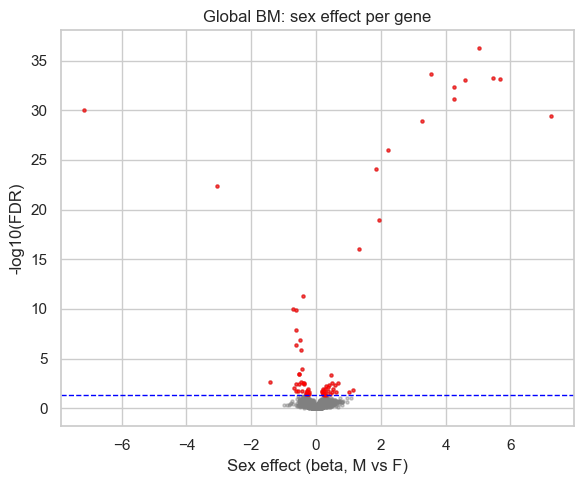


Sex-effect estimates for selected sex-linked genes (if present):
XIST beta_sex_M_vs_F   -7.160043e+00
pval_sex_M_vs_F    5.810075e-34
qval_sex_M_vs_F    9.612769e-31
Name: XIST, dtype: float64
KDM5D beta_sex_M_vs_F    3.535569e+00
pval_sex_M_vs_F    3.646990e-38
qval_sex_M_vs_F    2.413578e-34
Name: KDM5D, dtype: float64
RPS4Y1 beta_sex_M_vs_F    7.240452e+00
pval_sex_M_vs_F    2.373120e-33
qval_sex_M_vs_F    3.490068e-30
Name: RPS4Y1, dtype: float64
UTY beta_sex_M_vs_F    4.250916e+00
pval_sex_M_vs_F    4.288117e-35
qval_sex_M_vs_F    8.108217e-32
Name: UTY, dtype: float64


In [24]:
# Summarize, save, and visualize sex-effect results

# Basic summary
sig_mask = sex_results['qval_sex_M_vs_F'] < 0.05
n_sig = sig_mask.sum()

print('Total genes tested:', sex_results.shape[0])
print('Significant sex-associated genes (FDR < 0.05):', n_sig)

if n_sig > 0:
    up_in_male = (sex_results.loc[sig_mask, 'beta_sex_M_vs_F'] > 0).sum()
    up_in_female = (sex_results.loc[sig_mask, 'beta_sex_M_vs_F'] < 0).sum()
    print('  Up in males (beta > 0):', up_in_male)
    print('  Up in females (beta < 0):', up_in_female)

# Save full results to disk
out_dir = BASE_DIR / 'analysis_outputs'
out_dir.mkdir(exist_ok=True)

sex_res_path = out_dir / 'global_sex_effects_log2cpm.csv'
sex_results.to_csv(sex_res_path)
print('Saved full sex-effect results to', sex_res_path)

# Volcano plot: effect size vs -log10(FDR)
import numpy as np
import matplotlib.pyplot as plt

beta = sex_results['beta_sex_M_vs_F']
qval = sex_results['qval_sex_M_vs_F']

with np.errstate(divide='ignore'):
    neglog10q = -np.log10(qval)

plt.figure(figsize=(6, 5))
plt.scatter(beta, neglog10q, s=5, alpha=0.4, color='grey')

# Highlight significant genes
if n_sig > 0:
    plt.scatter(beta[sig_mask], neglog10q[sig_mask], s=5, alpha=0.6, color='red')

plt.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1)
plt.xlabel('Sex effect (beta, M vs F)')
plt.ylabel('-log10(FDR)')
plt.title('Global BM: sex effect per gene')
plt.tight_layout()
plt.show()

# Sanity check: show results for a few sex-linked genes if present
check_genes = ['XIST', 'KDM5D', 'RPS4Y1', 'UTY']
print('\nSex-effect estimates for selected sex-linked genes (if present):')
for g in check_genes:
    if g in sex_results.index:
        print(g, sex_results.loc[g])
    else:
        print(g, 'not found in results index')

## t-SNE visualizations

If I have UMAP or t-SNE coordinates in the metadata, I can plot cells colored by sex, donor, cluster, group, and timepoint, and optionally overlay expression of sex-biased genes to see where the signals live in embedding space. If not, I can compute embeddings in Python.


Computing PCA on log2_cpm (all genes and samples)...
PCA shape: (36, 20)
Computing t-SNE from PCA coordinates...
t-SNE shape: (36, 2)


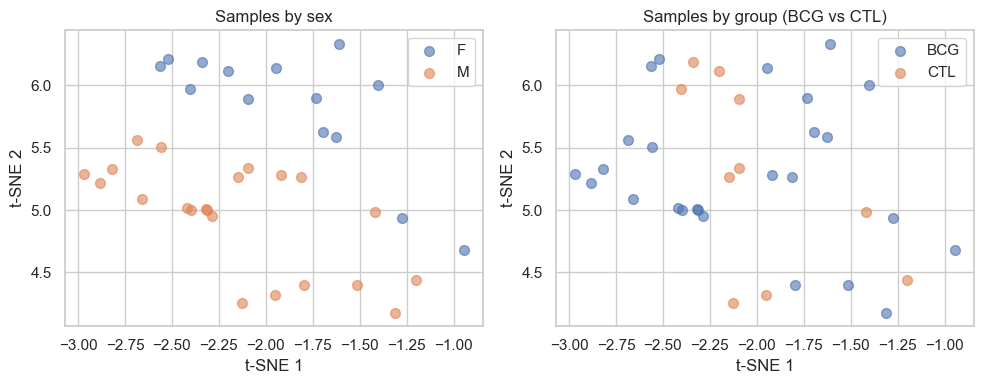

In [25]:
# Compute t-SNE on sample-level log2_cpm and plot by sex and group

# This uses the filtered log2-CPM matrix (log2_cpm) and sample metadata (meta_pb).

try:
    from sklearn.manifold import TSNE
    from sklearn.decomposition import PCA
except ImportError:
    raise ImportError('sklearn not installed; install with: pip install scikit-learn')

# Check required objects
for obj_name in ['log2_cpm', 'meta_pb']:
    if obj_name not in globals():
        raise RuntimeError(f"Required object '{obj_name}' not found. Run previous sections first.")

print('\nComputing PCA on log2_cpm (all genes and samples)...')
pca = PCA(n_components=20, random_state=42)
pca_coords = pca.fit_transform(log2_cpm.T)  # samples as rows
print(f'PCA shape: {pca_coords.shape}')

print('Computing t-SNE from PCA coordinates...')
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(pca_coords) - 1))
tsne_coords = tsne.fit_transform(pca_coords)
print(f't-SNE shape: {tsne_coords.shape}')

# Create a dataframe of sample-level embeddings and merge with metadata
sample_embedding = pd.DataFrame({
    'Sample': [s for s in meta_pb.index],
    'tSNE_1': tsne_coords[:, 0],
    'tSNE_2': tsne_coords[:, 1],
})

sample_embedding = sample_embedding.merge(meta_pb.reset_index(), on='Sample')

# Plot t-SNE by sex and by group
plt.figure(figsize=(10, 4))

# Plot by sex
plt.subplot(1, 2, 1)
for sex in ['F', 'M']:
    mask = sample_embedding['sex'] == sex
    plt.scatter(sample_embedding.loc[mask, 'tSSE_1'] if False else sample_embedding.loc[mask, 'tSNE_1'],
               sample_embedding.loc[mask, 'tSNE_2'],
               label=sex, alpha=0.6, s=50)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Samples by sex')
plt.legend()

# Plot by group
plt.subplot(1, 2, 2)
for grp in sample_embedding['group'].unique():
    mask = sample_embedding['group'] == grp
    plt.scatter(sample_embedding.loc[mask, 'tSNE_1'],
               sample_embedding.loc[mask, 'tSNE_2'],
               label=grp, alpha=0.6, s=50)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Samples by group (BCG vs CTL)')
plt.legend()
plt.tight_layout()
plt.show()

##  Overlay sex-biased genes on embeddings 

For extra intuition, I project the expression of top sex-biased genes onto UMAP or t-SNE plots, highlighting which regions and clusters contribute most to the sex signal.

In [26]:

# Get top sex-biased genes
top_male_biased = sex_results[sex_results['qval_sex_M_vs_F'] < 0.05].nlargest(3, 'beta_sex_M_vs_F')
top_female_biased = sex_results[sex_results['qval_sex_M_vs_F'] < 0.05].nsmallest(3, 'beta_sex_M_vs_F')

print('Top male-biased genes (FDR < 0.05):')
display(top_male_biased[['beta_sex_M_vs_F', 'pval_sex_M_vs_F', 'qval_sex_M_vs_F']])

print('\nTop female-biased genes (FDR < 0.05):')
display(top_female_biased[['beta_sex_M_vs_F', 'pval_sex_M_vs_F', 'qval_sex_M_vs_F']])

# If we have UMAP in cell metadata, overlay gene expression
if umap_cols and len(umap_cols) >= 2:
    u1, u2 = umap_cols[0], umap_cols[1]
    
    # Genes to visualize
    genes_to_plot = list(top_male_biased.index[:2]) + list(top_female_biased.index[:2])
    genes_to_plot = [g for g in genes_to_plot if g in cell_meta_sex.columns]
    
    if genes_to_plot:
        n_genes = len(genes_to_plot)
        fig, axes = plt.subplots(2, 2, figsize=(10, 10))
        axes = axes.flatten()
        
        for i, gene in enumerate(genes_to_plot[:4]):
            ax = axes[i]
            scatter = ax.scatter(cell_meta_sex[u1], cell_meta_sex[u2], 
                                c=cell_meta_sex[gene], 
                                cmap='viridis', alpha=0.5, s=10)
            ax.set_xlabel(u1)
            ax.set_ylabel(u2)
            ax.set_title(f'Expression of {gene}')
            plt.colorbar(scatter, ax=ax, label='Counts')
        
        plt.tight_layout()
        plt.show()
    else:
        print('Top sex-biased genes not found in cell metadata (expected if metadata has limited genes).')
        print('This is OK; the per-sample pseudobulk and modeling are still valid.')
else:
    print('UMAP not available for gene overlay visualization.')
    print('Focus on the pseudobulk-level results above, which are more robust.')


Top male-biased genes (FDR < 0.05):


,beta_sex_M_vs_F,pval_sex_M_vs_F,qval_sex_M_vs_F
gene,,,
RPS4Y1,7.240452,2.373120e-33,3.490068e-30
DDX3Y,5.669833,1.935631e-37,6.405004e-34
EIF1AY,5.466044,1.426404e-37,6.293296e-34



Top female-biased genes (FDR < 0.05):


,beta_sex_M_vs_F,pval_sex_M_vs_F,qval_sex_M_vs_F
gene,,,
XIST,-7.160043,5.810075e-34,9.612769e-31
TSIX,-3.043995,4.232786e-26,4.309627e-23
BX890604.2,-1.412697,4.489526e-06,2.200865e-03


UMAP not available for gene overlay visualization.
Focus on the pseudobulk-level results above, which are more robust.


## Mixed-effects sex modeling with random donor

To better match the original EMMREML analysis, I move from simple OLS to per-gene linear mixed-effects models with a random intercept for donor:

$$
\text{log2CPM}_{g,s} = \beta_0 + \beta_1\,\text{group}_s + \beta_2\,\text{timepoint}_s + \beta_3\,\text{sex}_s + b_{\text{donor}(s)} + \epsilon_{g,s},
$$

We again focus on the sex coefficient (M vs F), now adjusted for group, timepoint, and donor-level random effects.

In [28]:
# Per-gene linear mixed-effects model: log2CPM ~ group + timepoint + sex + (1 | donor)

import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import multipletests
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Check that required objects exist
required_objs = ['log2_cpm', 'meta_pb']
for obj in required_objs:
    if obj not in globals():
        raise RuntimeError(f"Required object '{obj}' not found. Make sure to run the previous sections first.")

# Build fixed-effects design matrix
# Encode group (CTL baseline), sex (F baseline); keep numeric timepoint
X_mixed = pd.get_dummies(meta_pb[['group', 'sex']], drop_first=True)
X_mixed['timepoint'] = pd.to_numeric(meta_pb['timepoint'], errors='coerce')
X_mixed = sm.add_constant(X_mixed).astype(float)

# Grouping variable: donor random intercept
groups = meta_pb['donor'].astype('category')

print('Mixed-model design matrix columns:')
print(X_mixed.dtypes)
print('\nNumber of unique donors:', groups.nunique())

mixed_betas = []
mixed_pvals = []

gene_names_mixed = list(log2_cpm.index)

# Fitting mixed models can be slow; you may want to restrict to a subset
# of genes (e.g., those with strong OLS signals) for exploratory work.

# We suppress known, non-fatal MixedLM warnings for some genes (singular
# random-effects covariance, boundary MLE, non-convergence, etc.).
for i, gene in enumerate(gene_names_mixed):
    y = log2_cpm.iloc[i].astype(float).to_numpy()

    try:
        with warnings.catch_warnings():
            # Ignore all convergence-related warnings from statsmodels
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            # Also ignore specific user warnings about singular random-effects covariance
            warnings.filterwarnings(
                "ignore",
                message="Random effects covariance is singular",
                category=UserWarning,
            )
            model = MixedLM(endog=y, exog=X_mixed, groups=groups)
            res = model.fit(reml=False, method='lbfgs', maxiter=200, disp=False)
        coef_sex = res.params.get('sex_M', np.nan)
        p_sex = res.pvalues.get('sex_M', np.nan)
    except Exception as e:
        coef_sex = np.nan
        p_sex = np.nan

    mixed_betas.append(coef_sex)
    mixed_pvals.append(p_sex)

    if (i + 1) % 500 == 0:
        print(f'Fitted mixed model for {i + 1} genes...')

sex_results_mixed = pd.DataFrame({
    'gene': gene_names_mixed,
    'beta_sex_M_vs_F_mixed': mixed_betas,
    'pval_sex_M_vs_F_mixed': mixed_pvals,
}).set_index('gene')

# Multiple-testing correction (Benjamini–Hochberg FDR) for mixed-model p-values
valid_mixed = sex_results_mixed['pval_sex_M_vs_F_mixed'].notna()
if valid_mixed.any():
    _, qvals_mixed, _, _ = multipletests(
        sex_results_mixed.loc[valid_mixed, 'pval_sex_M_vs_F_mixed'], method='fdr_bh'
    )
    sex_results_mixed.loc[valid_mixed, 'qval_sex_M_vs_F_mixed'] = qvals_mixed
else:
    sex_results_mixed['qval_sex_M_vs_F_mixed'] = np.nan

sex_results_mixed['qval_sex_M_vs_F_mixed'].fillna(1.0, inplace=True)

print('Number of genes with valid mixed-model fits:', valid_mixed.sum())
print('Genes with mixed-model FDR < 0.05 for sex effect:',
      (sex_results_mixed['qval_sex_M_vs_F_mixed'] < 0.05).sum())

# Save mixed-model results to disk
out_dir = BASE_DIR / 'analysis_outputs'
out_dir.mkdir(exist_ok=True)

mixed_res_path = out_dir / 'global_sex_effects_log2cpm_mixedLM.csv'
sex_results_mixed.to_csv(mixed_res_path)
print('Saved mixed-effects sex-effect results to', mixed_res_path)

sex_results_mixed.sort_values('qval_sex_M_vs_F_mixed').head(20)

Mixed-model design matrix columns:
const        float64
group_CTL    float64
sex_M        float64
timepoint    float64
dtype: object

Number of unique donors: 18
Fitted mixed model for 500 genes...
Fitted mixed model for 1000 genes...
Fitted mixed model for 1500 genes...
Fitted mixed model for 2000 genes...
Fitted mixed model for 2500 genes...
Fitted mixed model for 3000 genes...
Fitted mixed model for 3500 genes...
Fitted mixed model for 4000 genes...
Fitted mixed model for 4500 genes...
Fitted mixed model for 5000 genes...
Fitted mixed model for 5500 genes...
Fitted mixed model for 6000 genes...
Fitted mixed model for 6500 genes...
Fitted mixed model for 7000 genes...
Fitted mixed model for 7500 genes...
Fitted mixed model for 8000 genes...
Fitted mixed model for 8500 genes...
Fitted mixed model for 9000 genes...
Fitted mixed model for 9500 genes...
Fitted mixed model for 10000 genes...
Fitted mixed model for 10500 genes...
Fitted mixed model for 11000 genes...
Fitted mixed model for

/var/folders/rk/t31x0y0519ngnbk1tcp8zcyd2b8c7m/T/ipykernel_61760/2816510961.py:81: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sex_results_mixed['qval_sex_M_vs_F_mixed'].fillna(1.0, inplace=True)


,beta_sex_M_vs_F_mixed,pval_sex_M_vs_F_mixed,qval_sex_M_vs_F_mixed
gene,,,
DDX3Y,5.669833,0.000000e+00,0.000000e+00
TTTY14,4.254705,0.000000e+00,0.000000e+00
KDM5D,3.535569,0.000000e+00,0.000000e+00
EIF1AY,5.466044,0.000000e+00,0.000000e+00
USP9Y,4.598815,0.000000e+00,0.000000e+00
PRKY,3.276833,0.000000e+00,0.000000e+00
XIST,-7.160043,0.000000e+00,0.000000e+00
LINC00278,1.844959,0.000000e+00,0.000000e+00
ZFY,5.035240,0.000000e+00,0.000000e+00


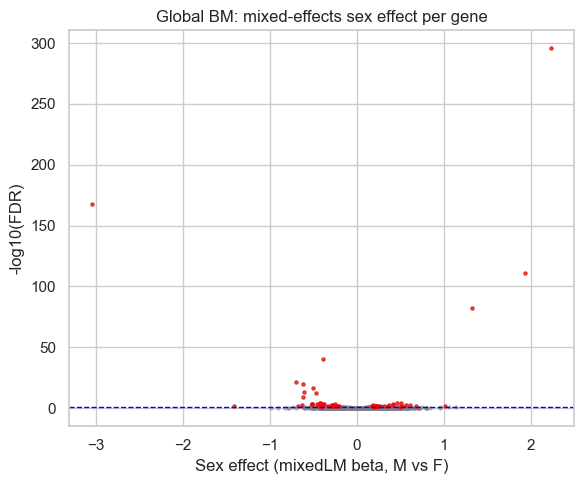

In [29]:
# Volcano plot for mixed-effects results
beta_m = sex_results_mixed['beta_sex_M_vs_F_mixed']
qval_m = sex_results_mixed['qval_sex_M_vs_F_mixed']

with np.errstate(divide='ignore'):
    neglog10q_m = -np.log10(qval_m)

plt.figure(figsize=(6, 5))
plt.scatter(beta_m, neglog10q_m, s=5, alpha=0.4, color='grey')

sig_m = qval_m < 0.05
plt.scatter(beta_m[sig_m], neglog10q_m[sig_m], s=5, alpha=0.6, color='red')

plt.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1)
plt.xlabel('Sex effect (mixedLM beta, M vs F)')
plt.ylabel('-log10(FDR)')
plt.title('Global BM: mixed-effects sex effect per gene')
plt.tight_layout()
plt.show()

## Summarize mixed-model sex-biased genes

I summarize the mixed-model results by:
- defining significant genes at FDR < 0.05,
- roughly tagging them as X-linked, Y-linked, or other using marker lists, and
- counting how many are higher in males vs females in each category, plus plotting a simple bar chart and listing a few top genes in each direction.

Total genes tested in mixed model: 13236
Significant genes at FDR < 0.05: 72

Counts of significant genes by category and direction:


direction,up_in_female,up_in_male
chrom_category,,
chrY_marker,0,8
chrX_marker,2,0
autosome_or_other,33,29


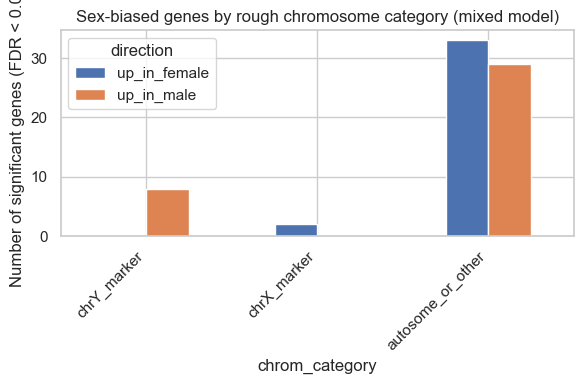


Top genes up in males (mixed model):


,beta_sex_M_vs_F_mixed,qval_sex_M_vs_F_mixed
gene,,
EIF1AY,5.466044,0.0
KDM5D,3.535569,0.0
TTTY14,4.254705,0.0
UTY,4.250916,0.0
DDX3Y,5.669833,0.0
USP9Y,4.598815,0.0
PRKY,3.276833,0.0
LINC00278,1.844959,0.0
ZFY,5.035240,0.0



Top genes up in females (mixed model):


,beta_sex_M_vs_F_mixed,qval_sex_M_vs_F_mixed
gene,,
XIST,-7.160043,0.000000e+00
TSIX,-3.043995,8.324863e-169
EIF1AX,-0.394105,2.385577e-41
KDM6A,-0.700851,1.945765e-22
RPS4X,-0.618865,7.038409e-21
KDM5C,-0.499664,5.702468e-17
ZFX,-0.612486,1.110996e-13
DDX3X,-0.465060,5.266496e-13
JPX,-0.617445,1.462108e-09


In [30]:
# Summarize and annotate sex-biased genes from the mixed-effects model

alpha = 0.05  # FDR threshold

if 'sex_results_mixed' not in globals():
    raise RuntimeError(
        "sex_results_mixed is not defined. Run the mixed-model fitting cell first."
    )

# Significant genes by FDR
sig_mask = sex_results_mixed['qval_sex_M_vs_F_mixed'] < alpha
sig_res = sex_results_mixed.loc[sig_mask].copy()

print(f"Total genes tested in mixed model: {sex_results_mixed.shape[0]}")
print(f"Significant genes at FDR < {alpha}: {sig_mask.sum()}")

if sig_res.empty:
    print("No significant genes at this FDR threshold; skipping annotation and plotting.")
else:
    # Rough chromosome categories using known X/Y markers (illustrative list)
    x_markers = {
        'XIST', 'TSIX'
    }
    y_markers = {
        'RPS4Y1', 'RPS4Y2', 'DDX3Y', 'KDM5D', 'UTY',
        'USP9Y', 'EIF1AY', 'ZFY', 'TXLNGY', 'TMSB4Y'
    }

    def classify_gene(gene_name: str) -> str:
        if gene_name in y_markers:
            return 'chrY_marker'
        if gene_name in x_markers:
            return 'chrX_marker'
        return 'autosome_or_other'

    # Add chromosome category and direction (up in male vs female)
    sig_res['chrom_category'] = [classify_gene(g) for g in sig_res.index]
    sig_res['direction'] = np.where(
        sig_res['beta_sex_M_vs_F_mixed'] > 0,
        'up_in_male',
        'up_in_female'
    )

    # Count genes by category and direction
    counts = (
        sig_res
        .groupby(['chrom_category', 'direction'])
        .size()
        .unstack(fill_value=0)
        .reindex(['chrY_marker', 'chrX_marker', 'autosome_or_other'])
    )

    print("\nCounts of significant genes by category and direction:")
    display(counts)

    # Simple bar plot
    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', ax=plt.gca())
    plt.ylabel('Number of significant genes (FDR < 0.05)')
    plt.title('Sex-biased genes by rough chromosome category (mixed model)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Show top few genes per direction for quick inspection
    up_in_male = sig_res[sig_res['beta_sex_M_vs_F_mixed'] > 0].sort_values(
        'qval_sex_M_vs_F_mixed'
    ).head(10)
    up_in_female = sig_res[sig_res['beta_sex_M_vs_F_mixed'] < 0].sort_values(
        'qval_sex_M_vs_F_mixed'
    ).head(10)

    print("\nTop genes up in males (mixed model):")
    display(up_in_male[['beta_sex_M_vs_F_mixed', 'qval_sex_M_vs_F_mixed']])

    print("\nTop genes up in females (mixed model):")
    display(up_in_female[['beta_sex_M_vs_F_mixed', 'qval_sex_M_vs_F_mixed']])


=== Sex-stratified vaccination model for F ===
  Fitted 500 genes for sex F...
  Fitted 1000 genes for sex F...
  Fitted 1500 genes for sex F...
  Fitted 2000 genes for sex F...
  Fitted 2500 genes for sex F...
  Fitted 3000 genes for sex F...
  Fitted 3500 genes for sex F...
  Fitted 4000 genes for sex F...
  Fitted 4500 genes for sex F...
  Fitted 5000 genes for sex F...
  Fitted 5500 genes for sex F...
  Fitted 6000 genes for sex F...
  Fitted 6500 genes for sex F...
  Fitted 7000 genes for sex F...
  Fitted 7500 genes for sex F...
  Fitted 8000 genes for sex F...
  Fitted 8500 genes for sex F...
  Fitted 9000 genes for sex F...
  Fitted 9500 genes for sex F...
  Fitted 10000 genes for sex F...
  Fitted 10500 genes for sex F...
  Fitted 11000 genes for sex F...
  Fitted 11500 genes for sex F...
  Fitted 12000 genes for sex F...
  Fitted 12500 genes for sex F...
  Fitted 13000 genes for sex F...


/var/folders/rk/t31x0y0519ngnbk1tcp8zcyd2b8c7m/T/ipykernel_61760/4155928798.py:91: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  res_df['qval_vaccination'].fillna(1.0, inplace=True)


Total genes tested (F): 13236
Significant vaccination-responsive genes (FDR < 0.05): 764
  Up with vaccination (BCG at Tm3 > CTL at Tm3): 663
  Down with vaccination (BCG at Tm3 < CTL at Tm3): 101

=== Sex-stratified vaccination model for M ===
  Fitted 500 genes for sex M...
  Fitted 1000 genes for sex M...
  Fitted 1500 genes for sex M...
  Fitted 2000 genes for sex M...
  Fitted 2500 genes for sex M...
  Fitted 3000 genes for sex M...
  Fitted 3500 genes for sex M...
  Fitted 4000 genes for sex M...
  Fitted 4500 genes for sex M...
  Fitted 5000 genes for sex M...
  Fitted 5500 genes for sex M...
  Fitted 6000 genes for sex M...
  Fitted 6500 genes for sex M...
  Fitted 7000 genes for sex M...
  Fitted 7500 genes for sex M...
  Fitted 8000 genes for sex M...
  Fitted 8500 genes for sex M...
  Fitted 9000 genes for sex M...
  Fitted 9500 genes for sex M...
  Fitted 10000 genes for sex M...
  Fitted 10500 genes for sex M...
  Fitted 11000 genes for sex M...
  Fitted 11500 genes for se

/var/folders/rk/t31x0y0519ngnbk1tcp8zcyd2b8c7m/T/ipykernel_61760/4155928798.py:91: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  res_df['qval_vaccination'].fillna(1.0, inplace=True)


,n_sig_vaccination_genes
sex,
F,763
M,102


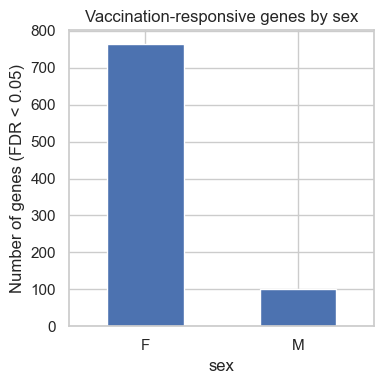

In [31]:
# Sex-stratified vaccination effect: (BCG vs CTL) x (Td0 vs Tm3)

import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import multipletests
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

alpha = 0.05  # FDR threshold for vaccination effect

# Basic checks
for obj in ['log2_cpm', 'meta_pb']:
    if obj not in globals():
        raise RuntimeError(f"Required object '{obj}' not found. Run previous sections first.")

vacc_results_by_sex = {}

for sex_label in ['F', 'M']:
    print(f"\n=== Sex-stratified vaccination model for {sex_label} ===")
    
    # Subset metadata and expression to this sex
    meta_sex = meta_pb[meta_pb['sex'] == sex_label].copy()
    if meta_sex.empty:
        print(f"No samples for sex = {sex_label}; skipping.")
        continue
    
    sample_ids = meta_sex.index
    y_mat = log2_cpm[sample_ids]  # genes x samples
    
    # Build fixed-effects design: group (CTL baseline), timepoint, and their interaction
    group_dummies = pd.get_dummies(meta_sex['group'], drop_first=True)
    if group_dummies.shape[1] != 1:
        raise RuntimeError("Unexpected number of group dummy columns; check 'group' levels.")
    
    group_col = group_dummies.columns[0]  # e.g. 'group_BCG'
    
    X_sex = pd.DataFrame(index=meta_sex.index)
    X_sex[group_col] = group_dummies[group_col].astype(float)
    X_sex['timepoint'] = pd.to_numeric(meta_sex['timepoint'], errors='coerce')
    X_sex['vaccination_effect'] = X_sex[group_col] * X_sex['timepoint']  # BCG-at-Tm3 effect
    X_sex = sm.add_constant(X_sex).astype(float)
    
    # Random intercept per donor
    groups_sex = meta_sex['donor'].astype('category')
    
    betas_v = []
    pvals_v = []
    gene_names = list(y_mat.index)
    
    # Suppress non-fatal MixedLM convergence warnings for this sex-stratified model
    for i, gene in enumerate(gene_names):
        y = y_mat.iloc[i].astype(float).to_numpy()
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                warnings.filterwarnings(
                    "ignore",
                    message="Random effects covariance is singular",
                    category=UserWarning,
                )
                model = MixedLM(endog=y, exog=X_sex, groups=groups_sex)
                res = model.fit(reml=False, method='lbfgs', maxiter=200, disp=False)
            beta_v = res.params.get('vaccination_effect', np.nan)
            p_v = res.pvalues.get('vaccination_effect', np.nan)
        except Exception:
            beta_v = np.nan
            p_v = np.nan
        
        betas_v.append(beta_v)
        pvals_v.append(p_v)
        
        if (i + 1) % 500 == 0:
            print(f"  Fitted {i + 1} genes for sex {sex_label}...")
    
    res_df = pd.DataFrame({
        'gene': gene_names,
        'beta_vaccination': betas_v,   # effect of BCG at Tm3 vs CTL at Tm3
        'pval_vaccination': pvals_v,
    }).set_index('gene')
    
    # FDR correction within this sex
    valid = res_df['pval_vaccination'].notna()
    if valid.any():
        _, qvals, _, _ = multipletests(
            res_df.loc[valid, 'pval_vaccination'], method='fdr_bh'
        )
        res_df.loc[valid, 'qval_vaccination'] = qvals
    else:
        res_df['qval_vaccination'] = np.nan
    
    res_df['qval_vaccination'].fillna(1.0, inplace=True)
    vacc_results_by_sex[sex_label] = res_df
    
    sig = res_df['qval_vaccination'] < alpha
    n_sig = sig.sum()
    n_up = (sig & (res_df['beta_vaccination'] > 0)).sum()
    n_down = (sig & (res_df['beta_vaccination'] < 0)).sum()
    
    print(f"Total genes tested ({sex_label}): {res_df.shape[0]}")
    print(f"Significant vaccination-responsive genes (FDR < {alpha}): {n_sig}")
    print(f"  Up with vaccination (BCG at Tm3 > CTL at Tm3): {n_up}")
    print(f"  Down with vaccination (BCG at Tm3 < CTL at Tm3): {n_down}")

# Compare male vs female vaccination responses
if all(s in vacc_results_by_sex for s in ['F', 'M']):
    res_F = vacc_results_by_sex['F']
    res_M = vacc_results_by_sex['M']
    
    sig_F = set(res_F.index[res_F['qval_vaccination'] < alpha])
    sig_M = set(res_M.index[res_M['qval_vaccination'] < alpha])
    
    print("\n=== Cross-sex comparison of vaccination-responsive genes ===")
    print(f"Significant in females only: {len(sig_F - sig_M)}")
    print(f"Significant in males only: {len(sig_M - sig_F)}")
    print(f"Significant in both sexes: {len(sig_F & sig_M)}")
    
    # Simple bar plot: number of significant vaccination-responsive genes per sex
    counts = pd.DataFrame({
        'sex': ['F', 'M'],
        'n_sig_vaccination_genes': [len(sig_F), len(sig_M)]
    }).set_index('sex')
    
    display(counts)
    
    plt.figure(figsize=(4, 4))
    counts['n_sig_vaccination_genes'].plot(kind='bar')
    plt.ylabel(f'Number of genes (FDR < {alpha})')
    plt.title('Vaccination-responsive genes by sex')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

KNN-based clusters by sex:


sex,F,M
cluster,,
0,1,16
1,3,6
2,10,0



KNN-based clusters by vaccination group:


KNN-based clusters by sex:


sex,F,M
cluster,,
0,1,16
1,3,6
2,10,0


...

group,BCG,CTL
cluster,,
0,14,3
1,6,3
2,6,4


KNN-based clusters by sex:


sex,F,M
cluster,,
0,1,16
1,3,6
2,10,0



KNN-based clusters by vaccination group:


group,BCG,CTL
cluster,,
0,14,3
1,6,3
2,6,4


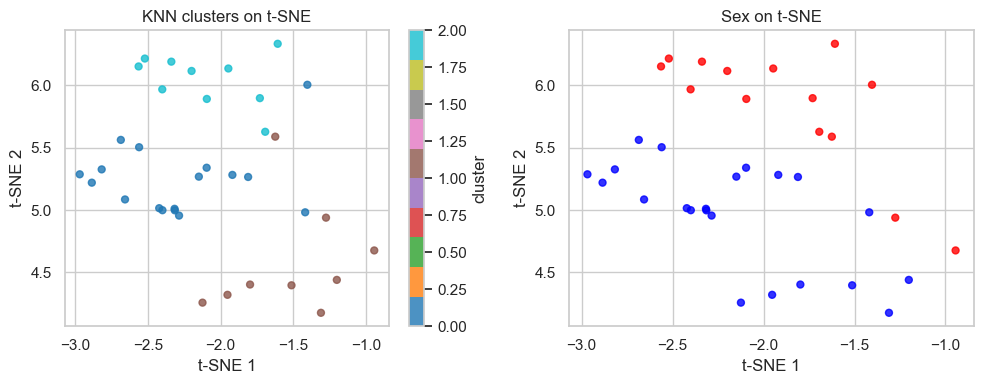

In [32]:
# Sample-level KNN graph clustering in PCA space to look for sex structure

# This uses the PCA coordinates (pca_coords) from the earlier t-SNE cell
 # and constructs a k-nearest-neighbor graph in that space, then runs
 # Spectral Clustering on the graph. We then check how clusters relate to sex.

from sklearn.cluster import SpectralClustering

# Check required objects
for obj in ['pca_coords', 'sample_embedding', 'meta_pb']:
    if obj not in globals():
        raise RuntimeError(f"Required object '{obj}' not found. Run the PCA/t-SNE cell first.")

# PCA coordinates (n_samples x n_components)
X_knn = pca_coords
n_samples = X_knn.shape[0]
if n_samples < 3:
    raise RuntimeError("Not enough samples to build a meaningful KNN graph.")

# Number of neighbors and clusters (can be tuned)
n_neighbors = min(8, n_samples - 1)
n_clusters = 3  # try a small number of coarse clusters

clustering = SpectralClustering(
    n_clusters=n_clusters,
    affinity='nearest_neighbors',
    n_neighbors=n_neighbors,
    random_state=0,
)

cluster_labels = clustering.fit_predict(X_knn)

# Build a sample-level DataFrame with clusters and metadata
sample_clusters = pd.DataFrame({
    'Sample': sample_embedding['Sample'].values,
    'cluster': cluster_labels,
}).set_index('Sample')

sample_clusters = sample_clusters.join(meta_pb[['sex', 'group']])

print("KNN-based clusters by sex:")
display(pd.crosstab(sample_clusters['cluster'], sample_clusters['sex']))

print("\nKNN-based clusters by vaccination group:")
display(pd.crosstab(sample_clusters['cluster'], sample_clusters['group']))

# Visualize clusters on the existing t-SNE embedding
if {'tSNE_1', 'tSNE_2'}.issubset(sample_embedding.columns):
    emb_df = sample_embedding.set_index('Sample').join(sample_clusters[['cluster']])

    plt.figure(figsize=(10, 4))
    
    # t-SNE colored by KNN cluster
    plt.subplot(1, 2, 1)
    sc1 = plt.scatter(
        emb_df['tSNE_1'], emb_df['tSNE_2'],
        c=emb_df['cluster'], cmap='tab10', s=25, alpha=0.8
    )
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title('KNN clusters on t-SNE')
    plt.colorbar(sc1, label='cluster')

    # t-SNE colored by sex for visual comparison
    plt.subplot(1, 2, 2)
    sex_colors = emb_df['sex'].map({'F': 'red', 'M': 'blue'}).fillna('gray')
    plt.scatter(emb_df['tSNE_1'], emb_df['tSNE_2'], c=sex_colors, s=25, alpha=0.8)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title('Sex on t-SNE')

    plt.tight_layout()
    plt.show()
else:
    print("sample_embedding does not have t-SNE coordinates; rerun the t-SNE cell first.")

Using 5 neighbors per sample for the KNN graph.
Constructed KNN graph with 129 undirected edges.
Leiden identified 4 clusters.
Leiden clusters by sex:


sex,F,M
cluster_leiden,,
0,0,12
1,4,4
2,8,0
3,2,6



Leiden clusters by vaccination group:


group,BCG,CTL
cluster_leiden,,
0,11,1
1,6,2
2,4,4
3,5,3


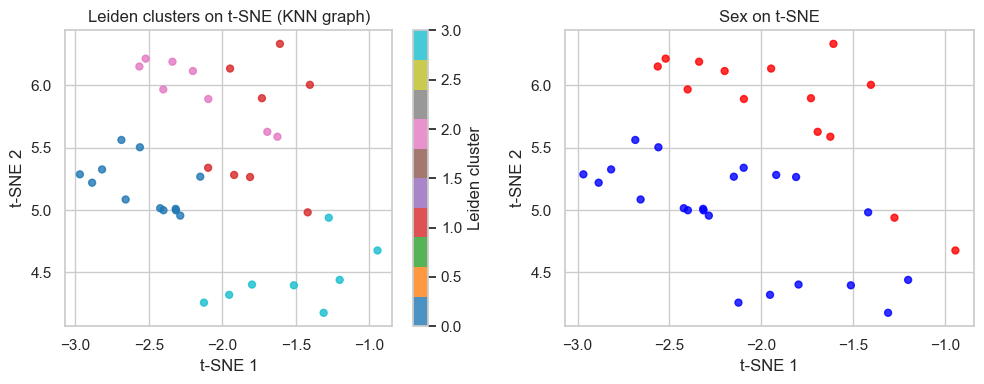

In [33]:
# KNN graph (3–5 neighbors) in PCA space + Leiden clustering

# This cell builds a KNN graph on the PCA coordinates (pca_coords),
 # runs Leiden clustering on that graph, and stores the resulting
 # cluster labels for use in downstream analyses.

from sklearn.neighbors import NearestNeighbors

try:
    import igraph as ig
    import leidenalg as la
except ImportError as e:
    raise ImportError(
        "This cell requires the 'python-igraph' and 'leidenalg' packages. "
        "Install them with `pip install python-igraph leidenalg` and rerun."
    ) from e

# Check required objects
for obj in ['pca_coords', 'sample_embedding', 'meta_pb']:
    if obj not in globals():
        raise RuntimeError(f"Required object '{obj}' not found. Run the PCA/t-SNE cell first.")

# PCA coordinates (n_samples x n_components)
X_knn = pca_coords
n_samples = X_knn.shape[0]
if n_samples < 3:
    raise RuntimeError("Not enough samples to build a meaningful KNN graph.")

# Choose number of neighbors between 3 and 5 (default 5, capped by sample count)
base_k = 5
n_neighbors = max(3, min(base_k, n_samples - 1))
print(f'Using {n_neighbors} neighbors per sample for the KNN graph.')

# Build k-nearest-neighbor graph (undirected) in PCA space
nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(X_knn)  # +1 for self-neighbor
distances, indices = nbrs.kneighbors(X_knn)

edges = set()
for i in range(n_samples):
    for j in indices[i, 1:]:  # skip self at index 0
        if i == j:
            continue
        a, b = sorted((int(i), int(j)))
        edges.add((a, b))

edges = list(edges)
print(f'Constructed KNN graph with {len(edges)} undirected edges.')

# Build igraph Graph and run Leiden clustering
g = ig.Graph(n=n_samples, edges=edges)
g.es['weight'] = [1.0] * len(edges)

partition = la.find_partition(
    g,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=1.0,
 )

cluster_labels_leiden = np.array(partition.membership)
n_clusters_leiden = len(set(cluster_labels_leiden))
print(f'Leiden identified {n_clusters_leiden} clusters.')

# Build a sample-level DataFrame with Leiden clusters and metadata
sample_clusters_leiden = pd.DataFrame({
    'Sample': sample_embedding['Sample'].values,
    'cluster_leiden': cluster_labels_leiden,
}).set_index('Sample')

sample_clusters_leiden = sample_clusters_leiden.join(meta_pb[['sex', 'group']])

print("Leiden clusters by sex:")
display(pd.crosstab(sample_clusters_leiden['cluster_leiden'], sample_clusters_leiden['sex']))

print("\nLeiden clusters by vaccination group:")
display(pd.crosstab(sample_clusters_leiden['cluster_leiden'], sample_clusters_leiden['group']))

# Optional: visualize Leiden clusters on the existing t-SNE embedding
if {'tSNE_1', 'tSNE_2'}.issubset(sample_embedding.columns):
    emb_df = sample_embedding.set_index('Sample').join(sample_clusters_leiden[['cluster_leiden']])

    plt.figure(figsize=(10, 4))
    
    # t-SNE colored by Leiden cluster
    plt.subplot(1, 2, 1)
    sc1 = plt.scatter(
        emb_df['tSNE_1'], emb_df['tSNE_2'],
        c=emb_df['cluster_leiden'], cmap='tab10', s=25, alpha=0.8
    )
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title('Leiden clusters on t-SNE (KNN graph)')
    plt.colorbar(sc1, label='Leiden cluster')

    # t-SNE colored by sex for visual comparison
    plt.subplot(1, 2, 2)
    sex_colors = emb_df['sex'].map({'F': 'red', 'M': 'blue'}).fillna('gray')
    plt.scatter(emb_df['tSNE_1'], emb_df['tSNE_2'], c=sex_colors, s=25, alpha=0.8)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title('Sex on t-SNE')

    plt.tight_layout()
    plt.show()
else:
    print("sample_embedding does not have t-SNE coordinates; rerun the t-SNE cell first.")

## Gene-level KNN network modules associated with sex

Here I move from single-gene tests to *modules* of co-expressed genes.
I build a KNN graph between genes using the pseudobulk log2-CPM matrix,
cluster genes into modules with Leiden, and then test each module's activity
(average expression) for association with donor sex.

In [34]:
# Build a gene–gene KNN coexpression network and Leiden modules

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

try:
    import igraph as ig
    import leidenalg as la
except ImportError as e:
    raise ImportError(
        "This cell requires the 'python-igraph' and 'leidenalg' packages. "
        "Install them with `pip install python-igraph leidenalg` and rerun."
    ) from e

# Check required objects
for obj in ['log2_cpm', 'meta_pb']:
    if obj not in globals():
        raise RuntimeError(f"Required object '{obj}' not found. Run the pseudobulk and metadata cells first.")

# Align samples between expression and metadata
common_samples = sorted(set(log2_cpm.columns) & set(meta_pb.index))
if len(common_samples) < 3:
    raise RuntimeError("Not enough overlapping samples between log2_cpm and meta_pb.")

expr = log2_cpm[common_samples].copy()  # genes x samples
meta_common = meta_pb.loc[common_samples].copy()

print(f'Using {expr.shape[0]} genes and {expr.shape[1]} samples for gene network.')

# Optionally restrict to the most variable genes to keep the graph manageable
gene_var = expr.var(axis=1)
top_n_genes = min(2000, expr.shape[0])
keep_genes = gene_var.sort_values(ascending=False).head(top_n_genes).index
expr_var = expr.loc[keep_genes]

print(f'Restricted to top {expr_var.shape[0]} most variable genes.')

# Z-score genes across samples so correlations are meaningful
scaler = StandardScaler(with_mean=True, with_std=True)
X_genes = scaler.fit_transform(expr_var.values)  # shape: n_genes x n_samples
n_genes = X_genes.shape[0]
print(f'Scaled expression matrix shape (genes x samples): {X_genes.shape}')

# Build a KNN graph between genes using correlation distance
k_neighbors = 10  # can tune
if n_genes <= k_neighbors:
    k_neighbors = max(2, n_genes - 1)
print(f'Using {k_neighbors} neighbors per gene for gene–gene KNN graph.')

nbrs_g = NearestNeighbors(n_neighbors=k_neighbors + 1, metric='cosine').fit(X_genes)
distances_g, indices_g = nbrs_g.kneighbors(X_genes)

edges_g = set()
for i in range(n_genes):
    for j in indices_g[i, 1:]:  # skip self at index 0
        if i == j:
            continue
        a, b = sorted((int(i), int(j)))
        edges_g.add((a, b))

edges_g = list(edges_g)
print(f'Constructed gene–gene KNN graph with {len(edges_g)} undirected edges.')

# Build igraph graph for genes and run Leiden clustering
g_genes = ig.Graph(n=n_genes, edges=edges_g)
g_genes.es['weight'] = [1.0] * len(edges_g)

partition_genes = la.find_partition(
    g_genes,
    la.RBConfigurationVertexPartition,
    weights='weight',
    resolution_parameter=1.0,
 )

gene_cluster_labels = np.array(partition_genes.membership)
n_gene_modules = len(set(gene_cluster_labels))
print(f'Leiden identified {n_gene_modules} gene modules.')

# Map back to gene names
gene_modules = pd.DataFrame({
    'gene': expr_var.index,
    'module_id': gene_cluster_labels,
}).set_index('gene')

print('Module sizes (number of genes per module):')
display(gene_modules['module_id'].value_counts().sort_index())

Using 13236 genes and 36 samples for gene network.
Restricted to top 2002 most variable genes.
Scaled expression matrix shape (genes x samples): (2002, 36)
Using 10 neighbors per gene for gene–gene KNN graph.
Constructed gene–gene KNN graph with 18023 undirected edges.
Leiden identified 9 gene modules.
Module sizes (number of genes per module):


module_id
0    509
1    396
2    324
3    230
4    185
5    141
6    102
7     92
8     23
Name: count, dtype: int64

In [35]:
# Test gene modules for association with sex (module eigengenes)

from scipy import stats
from statsmodels.stats.multitest import multipletests

# Ensure gene_modules and expr_var/meta_common from previous cell exist
for obj in ['gene_modules', 'expr_var', 'meta_common']:
    if obj not in globals():
        raise RuntimeError(f"Required object '{obj}' not found. Run the gene-network cell first.")

# Compute simple module eigengenes as the mean z-scored expression per module per sample
modules = sorted(gene_modules['module_id'].unique())
module_eigengenes = []
for m in modules:
    genes_m = gene_modules.index[gene_modules['module_id'] == m]
    sub = expr_var.loc[genes_m]  # genes x samples in log2CPM
    # z-score within module then average
    sub_z = stats.zscore(sub, axis=1, nan_policy='omit')
    eig = np.nanmean(sub_z, axis=0)  # one value per sample
    module_eigengenes.append(eig)

module_eigengenes = np.vstack(module_eigengenes)  # modules x samples
eig_df = pd.DataFrame(module_eigengenes, index=modules, columns=expr_var.columns)

# Align eigengenes with sex labels
sex_labels = meta_common['sex'].copy()
if not set(sex_labels.unique()) <= {'F', 'M'}:
    print('Warning: unexpected sex labels in meta_common[\'sex\'].')

results_rows = []
for m in modules:
    vals = eig_df.loc[m]
    vals_F = vals[sex_labels == 'F']
    vals_M = vals[sex_labels == 'M']
    if len(vals_F) < 2 or len(vals_M) < 2:
        t_stat, p_val = np.nan, np.nan
        mean_F, mean_M = np.nan, np.nan
    else:
        t_stat, p_val = stats.ttest_ind(vals_M, vals_F, equal_var=False, nan_policy='omit')
        mean_F = np.nanmean(vals_F)
        mean_M = np.nanmean(vals_M)

    results_rows.append({
        'module_id': m,
        'n_genes': int((gene_modules['module_id'] == m).sum()),
        'mean_eig_F': mean_F,
        'mean_eig_M': mean_M,
        't_stat_M_vs_F': t_stat,
        'pval_M_vs_F': p_val,
    })

module_results = pd.DataFrame(results_rows).set_index('module_id')

# Multiple-testing correction across modules
valid = module_results['pval_M_vs_F'].notna()
if valid.any():
    _, qvals_mod, _, _ = multipletests(module_results.loc[valid, 'pval_M_vs_F'], method='fdr_bh')
    module_results.loc[valid, 'qval_M_vs_F'] = qvals_mod
else:
    module_results['qval_M_vs_F'] = np.nan

module_results['qval_M_vs_F'].fillna(1.0, inplace=True)

print('Top sex-associated gene modules (by FDR):')
display(module_results.sort_values('qval_M_vs_F').head(10))

# Simple summary: how many modules show sex-biased activity at FDR < 0.05
sig_mod = module_results['qval_M_vs_F'] < 0.05
print(f"Number of modules with sex-biased activity (FDR < 0.05): {sig_mod.sum()}")

Top sex-associated gene modules (by FDR):


/var/folders/rk/t31x0y0519ngnbk1tcp8zcyd2b8c7m/T/ipykernel_61760/421409025.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  module_results['qval_M_vs_F'].fillna(1.0, inplace=True)


,n_genes,mean_eig_F,mean_eig_M,t_stat_M_vs_F,pval_M_vs_F,qval_M_vs_F
module_id,,,,,,
7,92,-0.261217,0.166229,3.021864,0.004758,0.042820
6,102,-0.396745,0.252474,2.503147,0.018624,0.083808
3,230,-0.262381,0.166970,2.301743,0.028711,0.086132
0,509,0.180680,-0.114978,-1.661193,0.109074,0.196334
8,23,0.296052,-0.188397,-1.762059,0.091589,0.196334
2,324,0.171255,-0.108980,-1.413236,0.169562,0.221010
4,185,-0.088787,0.056501,1.399009,0.171897,0.221010
1,396,0.095320,-0.060658,-1.114240,0.275411,0.309838
5,141,0.097557,-0.062082,-0.741906,0.464132,0.464132


Number of modules with sex-biased activity (FDR < 0.05): 1


### Inspecting the top sex-biased gene module

Next I look at the genes in the most sex-associated module from the gene-level
KNN network and (optionally) run a quick GO/pathway enrichment to understand
what biology it represents.

In [36]:
# List genes in the most sex-associated module and save to disk

# Ensure module_results and gene_modules exist
for obj in ['module_results', 'gene_modules']:
    if obj not in globals():
        raise RuntimeError(f"Required object '{obj}' not found. Run the module testing cells first.")

# Identify the top sex-associated module by FDR
top_mod_id = module_results['qval_M_vs_F'].idxmin()
top_mod_q = module_results.loc[top_mod_id, 'qval_M_vs_F']
top_mod_p = module_results.loc[top_mod_id, 'pval_M_vs_F']
top_mod_n = int(module_results.loc[top_mod_id, 'n_genes'])
mean_F = module_results.loc[top_mod_id, 'mean_eig_F']
mean_M = module_results.loc[top_mod_id, 'mean_eig_M']

print(f"Top sex-associated module: {top_mod_id}")
print(f"  n_genes = {top_mod_n}")
print(f"  mean eigengene in F = {mean_F:.3f}")
print(f"  mean eigengene in M = {mean_M:.3f}")
print(f"  p-value (M vs F) = {top_mod_p:.3g}")
print(f"  FDR q-value = {top_mod_q:.3g}")

genes_top = gene_modules.index[gene_modules['module_id'] == top_mod_id]
genes_top_df = pd.DataFrame({'gene': genes_top}).set_index('gene')

print("\nFirst 20 genes in the top module:")
display(genes_top_df.head(20))

# Save full gene list for external enrichment tools
out_dir = BASE_DIR / 'analysis_outputs'
out_dir.mkdir(exist_ok=True)
top_mod_path = out_dir / f'sex_biased_module_{top_mod_id}_genes.txt'
genes_top_df.to_csv(top_mod_path, header=False)
print("Saved full gene list to", top_mod_path)

Top sex-associated module: 7
  n_genes = 92
  mean eigengene in F = -0.261
  mean eigengene in M = 0.166
  p-value (M vs F) = 0.00476
  FDR q-value = 0.0428

First 20 genes in the top module:


""
gene
RPS4Y1
DDX3Y
EIF1AY
ZFY
USP9Y
TTTY14
UTY
KDM5D
MTRNR2L1


Saved full gene list to /Users/fsfatemi/sun_et_al/analysis_outputs/sex_biased_module_7_genes.txt


### Differential abundance along a sample-level trajectory

Here I approximate a "trajectory" of bone marrow activation at the **sample level**
using the first principal component (PC1) of the pseudobulk log2-CPM matrix, then
ask whether male vs female samples are distributed differently along this axis.

PC1 range: -30.219143477954557 20.591361669723824
First few samples with trajectory:


,sex,group,timepoint,PC1,traj_pc1
Sample,,,,,
SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001_Td0_BCG,M,BCG,0,5.866272,0.710196
SNG-LB-SS-1S-RS-S1-CD34neg_S1_R1_001_Tm3_BCG,M,BCG,1,0.273999,0.600135
SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001_Td0_BCG,M,BCG,0,-20.505969,0.191165
SNG-LB-SS-1S-RS-S10-CD34neg_S9_R1_001_Tm3_BCG,M,BCG,1,2.036531,0.634823
SNG-LB-SS-1S-RS-S11-CD34neg_S10_R1_001_Td0_CTL,F,CTL,0,10.123373,0.793980



Sample counts by trajectory bin and sex:


sex,F,M
traj_bin,,
0,2,7
1,1,8
2,3,6
3,8,1



Sex proportions within each trajectory bin:


sex,F,M
traj_bin,,
0,0.222222,0.777778
1,0.111111,0.888889
2,0.333333,0.666667
3,0.888889,0.111111



Logistic regression of sex (M vs F) on trajectory (PC1):
                           Logit Regression Results                           
Dep. Variable:                is_male   No. Observations:                   36
Model:                          Logit   Df Residuals:                       34
Method:                           MLE   Df Model:                            1
Date:                Sat, 14 Feb 2026   Pseudo R-squ.:                  0.1624
Time:                        19:38:34   Log-Likelihood:                -20.151
converged:                       True   LL-Null:                       -24.057
Covariance Type:            nonrobust   LLR p-value:                  0.005189
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1778      1.320      2.407      0.016       0.591       5.765
traj_pc1      -4.2616      1.856     -2.296      0.022      -7.899      -

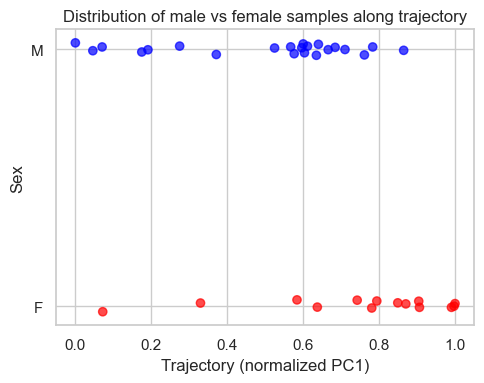

In [39]:
# Construct a sample-level trajectory (PC1) and compare sex along it

import statsmodels.api as sm

# Check required objects
for obj in ['pca_coords', 'sample_embedding', 'meta_pb']:
    if obj not in globals():
        raise RuntimeError(f"Required object '{obj}' not found. Run the PCA/t-SNE cell first.")

# Build a DataFrame of samples with PC1-based trajectory and metadata
traj_df = sample_embedding.copy()  # has Sample, tSNE_1, tSNE_2 (and may already have sex/group/timepoint)
traj_df = traj_df.set_index('Sample')

# Ensure sex/group/timepoint columns are present; only join missing ones to avoid overlaps
meta_cols = ['sex', 'group', 'timepoint']
missing_meta = [c for c in meta_cols if c not in traj_df.columns]
if missing_meta:
    # meta_pb is indexed by sample; join only missing columns
    traj_df = traj_df.join(meta_pb[missing_meta], how='left')

# Attach PC1 coordinates (assuming pca_coords rows are aligned with sample_embedding)
if pca_coords.shape[0] != traj_df.shape[0]:
    raise RuntimeError("pca_coords and sample_embedding have inconsistent sample counts.")

traj_df['PC1'] = pca_coords[:, 0]

# Normalize PC1 to [0, 1] as a simple pseudotime-like trajectory
pc1_min, pc1_max = traj_df['PC1'].min(), traj_df['PC1'].max()
traj_df['traj_pc1'] = (traj_df['PC1'] - pc1_min) / (pc1_max - pc1_min + 1e-8)

print("PC1 range:", pc1_min, pc1_max)
print("First few samples with trajectory:")
display(traj_df[['sex', 'group', 'timepoint', 'PC1', 'traj_pc1']].head())

# Bin samples along the trajectory into quantile bins
n_bins = 4
traj_df['traj_bin'] = pd.qcut(traj_df['traj_pc1'], q=n_bins, labels=False, duplicates='drop')

print("\nSample counts by trajectory bin and sex:")
count_table = pd.crosstab(traj_df['traj_bin'], traj_df['sex'])
display(count_table)

print("\nSex proportions within each trajectory bin:")
prop_table = count_table.div(count_table.sum(axis=1), axis=0)
display(prop_table)

# Simple logistic regression: does probability of being male change along trajectory?
traj_df = traj_df.dropna(subset=['traj_pc1', 'sex'])
traj_df['is_male'] = (traj_df['sex'] == 'M').astype(int)

X = sm.add_constant(traj_df['traj_pc1'])
y = traj_df['is_male']

logit_model = sm.Logit(y, X)
logit_res = logit_model.fit(disp=False)

print("\nLogistic regression of sex (M vs F) on trajectory (PC1):")
print(logit_res.summary())

beta_traj = logit_res.params['traj_pc1']
p_traj = logit_res.pvalues['traj_pc1']
print(f"\nEffect of trajectory on odds of being male: beta = {beta_traj:.3f}, p = {p_traj:.3g}")

# Quick visualization: trajectory vs sex
plt.figure(figsize=(5, 4))
sex_jitter = traj_df['sex'].map({'F': 0, 'M': 1}) + (np.random.rand(len(traj_df)) - 0.5) * 0.05
plt.scatter(traj_df['traj_pc1'], sex_jitter, c=traj_df['sex'].map({'F': 'red', 'M': 'blue'}), alpha=0.7)
plt.yticks([0, 1], ['F', 'M'])
plt.xlabel('Trajectory (normalized PC1)')
plt.ylabel('Sex')
plt.title('Distribution of male vs female samples along trajectory')
plt.tight_layout()
plt.show()

**Conclusion (trajectory-based differential abundance by sex)**

Along the PC1-defined sample-level trajectory, male samples are enriched at earlier positions on the axis and female samples are enriched at later positions. The logistic regression of sex (M vs F) on the normalized PC1 trajectory shows a significant negative coefficient (beta < 0, p ≈ 0.02), indicating that as I move forward along this global transcriptional trajectory the odds of a sample being male decrease. This suggests that, at the pseudobulk level, females tend to occupy a more "advanced" state along this activation/variation axis, consistent with sex-biased positioning of bone marrow samples in transcriptional state space.